In [24]:
! pip install pandas 
! pip install numpy 
! pip install matplotlib 
! pip install seaborn 
! pip install scikit-learn 


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 


In [26]:
df=pd.read_csv('Dataset/messy_time_series_sensor_interview_practice.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6505 entries, 0 to 6504
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Datetime           6502 non-null   str    
 1   Machine_ID         6505 non-null   str    
 2   Load_pct           6505 non-null   float64
 3   Motor_Speed_rpm    6505 non-null   float64
 4   Pressure_bar       6343 non-null   float64
 5   Flow_L_min         6280 non-null   float64
 6   Temperature_C      6389 non-null   float64
 7   Vibration_mm_s     6310 non-null   float64
 8   Power_kW           6407 non-null   float64
 9   Target_Temp_30min  6502 non-null   float64
 10  Operating_Mode     6480 non-null   str    
dtypes: float64(8), str(3)
memory usage: 559.2 KB


In [27]:
df.isna().sum()
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
6500    False
6501    False
6502    False
6503    False
6504    False
Length: 6505, dtype: bool

## 1.Load and inspect the data: head(), shape, info(), describe(), missing values, duplicates.
## 2.Clean Datetime, sort chronologically, handle invalid timestamps and duplicates.
## 3.Explore sensor relationships and identify suspicious values/outliers.
## 4.Decide how to handle missing sensor readings.
## 5.Create useful time-series features such as lags, rolling means/std, differences, and time features.
## 6.Split the data chronologically, not randomly.
## 7.Train a simple baseline and then an ML model such as Random Forest or gradient boosting.
## 8.Evaluate using MAE/RMSE/R² and inspect prediction errors.
## 9.Explain possible data leakage and what you would improve with more time.

In [28]:
df.head(5)

,Datetime,Machine_ID,Load_pct,Motor_Speed_rpm,Pressure_bar,Flow_L_min,Temperature_C,Vibration_mm_s,Power_kW,Target_Temp_30min,Operating_Mode
0,2026-02-09 03:40:00,M-07,71.336885,1867.643959,4.405118,170.475685,57.833549,3.243313,48.403302,56.290669,normal
1,2026-01-22 21:30:00,M-07,45.140213,1698.371360,4.073542,156.739860,46.330964,1.734030,37.393896,46.157163,low
2,2026-02-13 13:00:00,M-07,62.523756,1773.549882,NaN,166.780255,56.913850,4.370235,44.642624,57.022381,normal
3,2026-01-02 12:10:00,M-07,64.442583,1788.133024,4.388842,168.786363,50.591424,2.128702,46.794308,49.284589,normal
4,2026-01-17 05:50:00,M-07,79.299141,1834.032814,4.721164,175.385098,55.121338,1.931995,50.561236,54.618376,high


In [29]:
df['Datetime']=pd.to_datetime(df['Datetime'],format='mixed', dayfirst=True, errors='coerce')
df.isna().sum()
#df.head(5)
df.dropna(subset=['Datetime'],inplace=True)
df.isna().sum()
df['Datetime'].is_monotonic_decreasing

df=df.sort_values('Datetime').reset_index(drop=True)
df['Datetime'].is_monotonic_increasing

True

In [30]:
df.head(5)

,Datetime,Machine_ID,Load_pct,Motor_Speed_rpm,Pressure_bar,Flow_L_min,Temperature_C,Vibration_mm_s,Power_kW,Target_Temp_30min,Operating_Mode
0,2026-01-01 00:00:00,M-07,60.914151,1777.487902,4.243048,161.042305,48.602242,1.776836,45.258398,49.676197,normal
1,2026-01-01 00:10:00,M-07,58.880734,1750.683710,4.222401,158.107628,49.135117,2.152308,44.184184,49.781835,normal
2,2026-01-01 00:20:00,M-07,66.214298,1802.225655,4.416315,167.594636,48.944903,1.756121,46.354827,50.703747,normal
3,2026-01-01 00:30:00,M-07,68.671166,1888.027695,4.312771,172.871787,49.676197,2.060962,49.079252,51.725034,normal
4,2026-01-01 00:40:00,M-07,61.772075,1812.921497,4.329585,157.119027,49.781835,1.792895,47.715013,50.135291,normal


In [31]:
df['time/s']=(df['Datetime']-df['Datetime'].min()).dt.total_seconds()
time_diff= df['time/s'].diff()
#display(df[['dt','Datetime']])
#print(time_diff.value_counts())


#df[df['Datetime'].duplicated(keep=False)]

duplicated_id= df['Datetime'].duplicated(keep=False)
NAN_id=df['Operating_Mode'].isna()
print(duplicated_id)
print(NAN_id)

df=df[~(duplicated_id&NAN_id)].copy()

print(df['Datetime'].duplicated(keep=False).sum())




0       False
1       False
2       False
3       False
4       False
        ...  
6494    False
6495    False
6496    False
6497    False
6498    False
Name: Datetime, Length: 6499, dtype: bool
0       False
1       False
2       False
3       False
4       False
        ...  
6494    False
6495    False
6496    False
6497    False
6498    False
Name: Operating_Mode, Length: 6499, dtype: bool
0


In [32]:
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
Index: 6474 entries, 0 to 6498
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Datetime           6474 non-null   datetime64[us]
 1   Machine_ID         6474 non-null   str           
 2   Load_pct           6474 non-null   float64       
 3   Motor_Speed_rpm    6474 non-null   float64       
 4   Pressure_bar       6312 non-null   float64       
 5   Flow_L_min         6249 non-null   float64       
 6   Temperature_C      6358 non-null   float64       
 7   Vibration_mm_s     6280 non-null   float64       
 8   Power_kW           6377 non-null   float64       
 9   Target_Temp_30min  6471 non-null   float64       
 10  Operating_Mode     6474 non-null   str           
 11  time/s             6474 non-null   float64       
dtypes: datetime64[us](1), float64(9), str(2)
memory usage: 657.5 KB


Datetime               0
Machine_ID             0
Load_pct               0
Motor_Speed_rpm        0
Pressure_bar         162
Flow_L_min           225
Temperature_C        116
Vibration_mm_s       194
Power_kW              97
Target_Temp_30min      3
Operating_Mode         0
time/s                 0
dtype: int64

In [33]:
df['dt']= df['time/s'].diff()
print(df['dt'].value_counts())

dt
600.0        6451
1200.0          8
2506200.0       5
2419800.0       4
55800.0         1
808800.0        1
108000.0        1
756600.0        1
1210200.0       1
Name: count, dtype: int64


In [34]:
print(df[['dt','time/s']])

         dt      time/s
0       NaN         0.0
1     600.0       600.0
2     600.0      1200.0
3     600.0      1800.0
4     600.0      2400.0
...     ...         ...
6494  600.0  29027400.0
6495  600.0  29028000.0
6496  600.0  29028600.0
6497  600.0  29029200.0
6498  600.0  29029800.0

[6474 rows x 2 columns]


In [35]:
df[df['dt']>1200][['Datetime','Machine_ID','dt']]

,Datetime,Machine_ID,dt
290,2026-01-03 15:20:00,M-07,55800.0
291,2026-01-13 00:00:00,M-07,808800.0
3323,2026-02-04 05:50:00,M-07,108000.0
3324,2026-02-13 00:00:00,M-07,756600.0
3613,2026-03-01 00:00:00,M-07,1210200.0
3900,2026-04-01 00:00:00,M-07,2506200.0
4188,2026-05-01 00:00:00,M-07,2419800.0
4479,2026-06-01 00:00:00,M-07,2506200.0
4767,2026-07-01 00:00:00,M-07,2419800.0
5055,2026-08-01 00:00:00,M-07,2506200.0


In [36]:
df.isna().sum()

Datetime               0
Machine_ID             0
Load_pct               0
Motor_Speed_rpm        0
Pressure_bar         162
Flow_L_min           225
Temperature_C        116
Vibration_mm_s       194
Power_kW              97
Target_Temp_30min      3
Operating_Mode         0
time/s                 0
dt                     1
dtype: int64

In [37]:
df[['Machine_ID','Operating_Mode']].value_counts()
df['Operating_Mode']=df['Operating_Mode'].str.lower()
df[['Machine_ID','Operating_Mode']].value_counts()

Machine_ID  Operating_Mode
M-07        normal            3309
            high              1590
            low               1575
Name: count, dtype: int64

In [38]:
mode_mapping={
    'low': 1,
    'normal':2,
    'high':3
}

df['Operating_Mode']=df['Operating_Mode'].map(mode_mapping).copy()

df.head()

,Datetime,Machine_ID,Load_pct,Motor_Speed_rpm,Pressure_bar,Flow_L_min,Temperature_C,Vibration_mm_s,Power_kW,Target_Temp_30min,Operating_Mode,time/s,dt
0,2026-01-01 00:00:00,M-07,60.914151,1777.487902,4.243048,161.042305,48.602242,1.776836,45.258398,49.676197,2,0.0,NaN
1,2026-01-01 00:10:00,M-07,58.880734,1750.683710,4.222401,158.107628,49.135117,2.152308,44.184184,49.781835,2,600.0,600.0
2,2026-01-01 00:20:00,M-07,66.214298,1802.225655,4.416315,167.594636,48.944903,1.756121,46.354827,50.703747,2,1200.0,600.0
3,2026-01-01 00:30:00,M-07,68.671166,1888.027695,4.312771,172.871787,49.676197,2.060962,49.079252,51.725034,2,1800.0,600.0
4,2026-01-01 00:40:00,M-07,61.772075,1812.921497,4.329585,157.119027,49.781835,1.792895,47.715013,50.135291,2,2400.0,600.0


In [39]:

Target='Target_Temp_30min'

feature_col=[
    'Load_pct',
    'Motor_Speed_rpm',
    'Pressure_bar',
    'Flow_L_min',
    'Temperature_C',
    'Vibration_mm_s',
    'Power_kW',
    'Operating_Mode']

#df=df.dropna(subset=[Target]).copy()
#df.info()

df[feature_col].isna().sum()
#df.info()

Load_pct             0
Motor_Speed_rpm      0
Pressure_bar       162
Flow_L_min         225
Temperature_C      116
Vibration_mm_s     194
Power_kW            97
Operating_Mode       0
dtype: int64

In [40]:
df.head()
df.loc[0,'dt']=0
df.head()

stage_index=df['dt']>1200
print(stage_index)

df['test_id']=(df['dt']>1200).cumsum()
print(df['test_id'])

df.head(5)

0       False
1       False
2       False
3       False
4       False
        ...  
6494    False
6495    False
6496    False
6497    False
6498    False
Name: dt, Length: 6474, dtype: bool
0        0
1        0
2        0
3        0
4        0
        ..
6494    14
6495    14
6496    14
6497    14
6498    14
Name: test_id, Length: 6474, dtype: int64


,Datetime,Machine_ID,Load_pct,Motor_Speed_rpm,Pressure_bar,Flow_L_min,Temperature_C,Vibration_mm_s,Power_kW,Target_Temp_30min,Operating_Mode,time/s,dt,test_id
0,2026-01-01 00:00:00,M-07,60.914151,1777.487902,4.243048,161.042305,48.602242,1.776836,45.258398,49.676197,2,0.0,0.0,0
1,2026-01-01 00:10:00,M-07,58.880734,1750.683710,4.222401,158.107628,49.135117,2.152308,44.184184,49.781835,2,600.0,600.0,0
2,2026-01-01 00:20:00,M-07,66.214298,1802.225655,4.416315,167.594636,48.944903,1.756121,46.354827,50.703747,2,1200.0,600.0,0
3,2026-01-01 00:30:00,M-07,68.671166,1888.027695,4.312771,172.871787,49.676197,2.060962,49.079252,51.725034,2,1800.0,600.0,0
4,2026-01-01 00:40:00,M-07,61.772075,1812.921497,4.329585,157.119027,49.781835,1.792895,47.715013,50.135291,2,2400.0,600.0,0


In [41]:
df['test_id'].value_counts()

test_id
2     3020
0      288
4      288
7      288
8      288
11     288
12     288
13     288
14     288
5      287
6      287
9      287
10     287
1        1
3        1
Name: count, dtype: int64

In [42]:
df=df[~df['test_id'].isin([1,3]) ]
df['test_id'].value_counts()
df.isna().sum()

Datetime               0
Machine_ID             0
Load_pct               0
Motor_Speed_rpm        0
Pressure_bar         162
Flow_L_min           225
Temperature_C        116
Vibration_mm_s       194
Power_kW              97
Target_Temp_30min      3
Operating_Mode         0
time/s                 0
dt                     0
test_id                0
dtype: int64

In [43]:
df=df.set_index('Datetime')

sensor_cols=[
    'Pressure_bar',
    'Flow_L_min',
    'Temperature_C',
    'Vibration_mm_s',
    'Power_kW',
    'Target_Temp_30min'
]


df[sensor_cols]=(
    df.groupby(['test_id'])[sensor_cols]
    .transform(lambda x:x.interpolate(method='time').bfill().ffill())
)

df[sensor_cols].isna().sum()

Pressure_bar         0
Flow_L_min           0
Temperature_C        0
Vibration_mm_s       0
Power_kW             0
Target_Temp_30min    0
dtype: int64

In [44]:
df.isna().sum()

Machine_ID           0
Load_pct             0
Motor_Speed_rpm      0
Pressure_bar         0
Flow_L_min           0
Temperature_C        0
Vibration_mm_s       0
Power_kW             0
Target_Temp_30min    0
Operating_Mode       0
time/s               0
dt                   0
test_id              0
dtype: int64

In [45]:
df.head()

,Machine_ID,Load_pct,Motor_Speed_rpm,Pressure_bar,Flow_L_min,Temperature_C,Vibration_mm_s,Power_kW,Target_Temp_30min,Operating_Mode,time/s,dt,test_id
Datetime,,,,,,,,,,,,,
2026-01-01 00:00:00,M-07,60.914151,1777.487902,4.243048,161.042305,48.602242,1.776836,45.258398,49.676197,2,0.0,0.0,0
2026-01-01 00:10:00,M-07,58.880734,1750.683710,4.222401,158.107628,49.135117,2.152308,44.184184,49.781835,2,600.0,600.0,0
2026-01-01 00:20:00,M-07,66.214298,1802.225655,4.416315,167.594636,48.944903,1.756121,46.354827,50.703747,2,1200.0,600.0,0
2026-01-01 00:30:00,M-07,68.671166,1888.027695,4.312771,172.871787,49.676197,2.060962,49.079252,51.725034,2,1800.0,600.0,0
2026-01-01 00:40:00,M-07,61.772075,1812.921497,4.329585,157.119027,49.781835,1.792895,47.715013,50.135291,2,2400.0,600.0,0


In [46]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 6472 entries, 2026-01-01 00:00:00 to 2026-12-02 23:50:00
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Machine_ID         6472 non-null   str    
 1   Load_pct           6472 non-null   float64
 2   Motor_Speed_rpm    6472 non-null   float64
 3   Pressure_bar       6472 non-null   float64
 4   Flow_L_min         6472 non-null   float64
 5   Temperature_C      6472 non-null   float64
 6   Vibration_mm_s     6472 non-null   float64
 7   Power_kW           6472 non-null   float64
 8   Target_Temp_30min  6472 non-null   float64
 9   Operating_Mode     6472 non-null   int64  
 10  time/s             6472 non-null   float64
 11  dt                 6472 non-null   float64
 12  test_id            6472 non-null   int64  
dtypes: float64(10), int64(2), str(1)
memory usage: 707.9 KB


<Axes: >

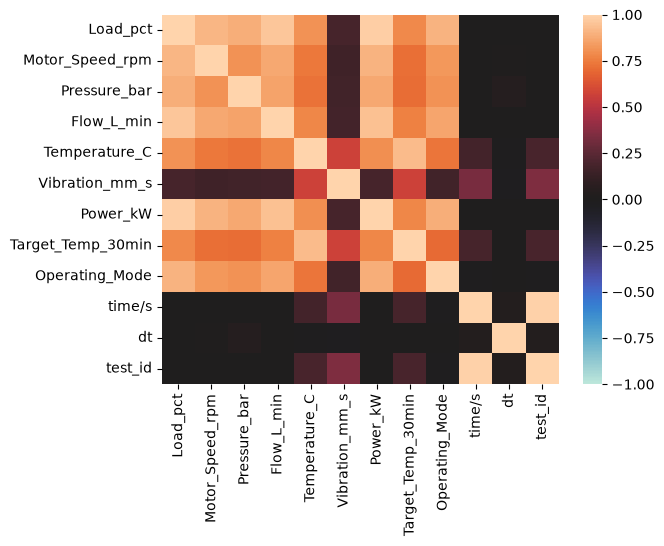

In [47]:
sns.heatmap(df.select_dtypes(include='number').corr(),vmin=-1.0, vmax=1.0,center=0.0)

In [48]:
print(feature_col)

['Load_pct', 'Motor_Speed_rpm', 'Pressure_bar', 'Flow_L_min', 'Temperature_C', 'Vibration_mm_s', 'Power_kW', 'Operating_Mode']


## build up the model 

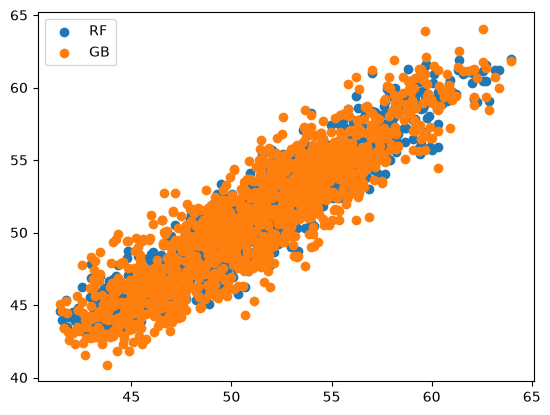

In [60]:
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

X=df[feature_col]
y=df[Target]

#print(y.isna().sum())

X_train, X_test, y_train, y_test = train_test_split (
    X,
    y,
    test_size=0.2,
    random_state=42
)
# use the RF
model_RF=RandomForestRegressor(
    n_estimators=200,
    random_state=42
)


model_RF.fit(X_train,y_train)

y_pred_RF=model_RF.predict(X_test)
y_pred0_RF=model_RF.predict(X_train)

MAE_RF=mean_absolute_error(y_test,y_pred_RF)
RMSE_RF=np.sqrt(mean_squared_error(y_test,y_pred_RF))
R2_RF=r2_score(y_test,y_pred_RF)

MAE0_RF=mean_absolute_error(y_train,y_pred0_RF)
RMSE0_RF=np.sqrt(mean_squared_error(y_train,y_pred0_RF))
R20_RF=r2_score(y_train,y_pred0_RF)

# use the GB 
model_GB = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    learning_rate=0.2
)
model_GB.fit(X_train, y_train)
y_pred_GB = model_GB.predict(X_test)
y_pred0_GB = model_GB.predict(X_train)

MAE0_GB=mean_absolute_error(y_train,y_pred0_GB)
RMSE0_GB=np.sqrt(mean_squared_error(y_train,y_pred0_GB))
R20_GB=r2_score(y_train,y_pred0_GB)

MAE_GB=mean_absolute_error(y_test,y_pred_GB)
RMSE_GB=np.sqrt(mean_squared_error(y_test,y_pred_GB))
R2_GB=r2_score(y_test,y_pred_GB)

plt.figure()
plt.scatter(y_test,y_pred_RF)
plt.scatter(y_test,y_pred_GB)
plt.legend(['RF','GB'])



In [61]:
metrics_summary= [
    {
        'Model name': 'Random Forest',
        'MAE': MAE_RF,
        'RMSE': RMSE_RF,
        'R2':R2_RF,
        'MAE0': MAE0_RF,
        'RMSE0': RMSE0_RF,
        'R20':R20_RF
    },

    {
        'Model name': 'Gradient Boosting',
        'MAE': MAE_GB,
        'RMSE': RMSE_GB,
        'R2':R2_GB,
        'MAE0': MAE0_GB,
        'RMSE0': RMSE0_GB,
        'R20':R20_GB
    }
]

display(pd.DataFrame(metrics_summary))

,Model name,MAE,RMSE,R2,MAE0,RMSE0,R20
0,Random Forest,1.213203,1.513839,0.891111,4.468482e-01,5.684384e-01,0.984518
1,Gradient Boosting,1.612303,2.018993,0.806316,1.220886e-08,1.486302e-08,1.000000


## importance analysis

Temperature_C      0.891291
Vibration_mm_s     0.024672
Load_pct           0.024619
Flow_L_min         0.015063
Pressure_bar       0.014876
Motor_Speed_rpm    0.014747
Power_kW           0.014350
Operating_Mode     0.000381
dtype: float64

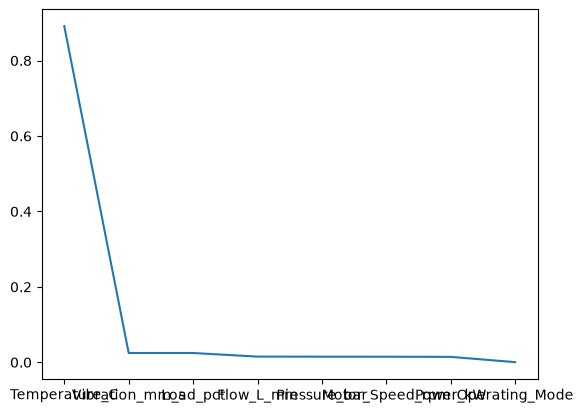

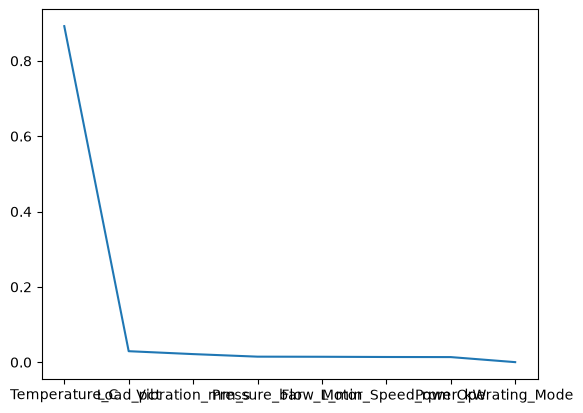

In [75]:
importance_RF= pd.Series(
    data=model_RF.feature_importances_,
    index=feature_col
).sort_values(ascending = False)

importance_GB= pd.Series(
    data=model_GB.feature_importances_,
    index=feature_col
).sort_values(ascending= False)

display(importance_RF)
plt.figure()

plt.plot(importance_RF)

plt.figure()

plt.plot(importance_GB)

In [91]:
importance_RF.values
print(type(importance_RF))
importance_RF.index
print(type(importance_GB))

importance_RF.dtype

importance_GB.iloc[0]
importance_GB.loc['Temperature_C']


<class 'pandas.Series'>
<class 'pandas.Series'>


np.float64(0.8922900147854742)

<Axes: >

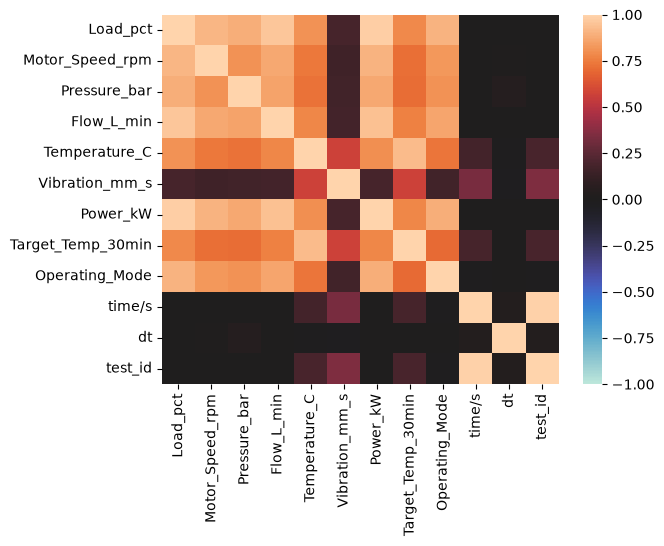

In [23]:
sns.heatmap(df.select_dtypes(include='number').corr( ),vmax =1.0,vmin=-1.0,center=0.0 )

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


X=df[feature_col]
y=df[Target]

X_train,X_test,y_train,y_test = train_test_split (
    X,
    y,
    test_size=0.2,
    random_state=42
)

model= RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train,y_train)

y_pred=model.predict(X_test)

mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)

print(f"MAE:{mae}")
print(f"RMSE:{rmse}")
print(f"r2:{r2}")

MAE:1.2200157435805294
RMSE:1.5198668233285677
r2:0.8902424216370586


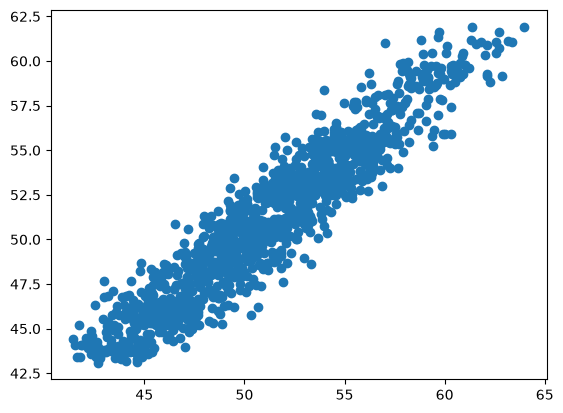

In [29]:
plt.figure()
plt.scatter(y_test,y_pred)

In [ ]:
plt.figure()

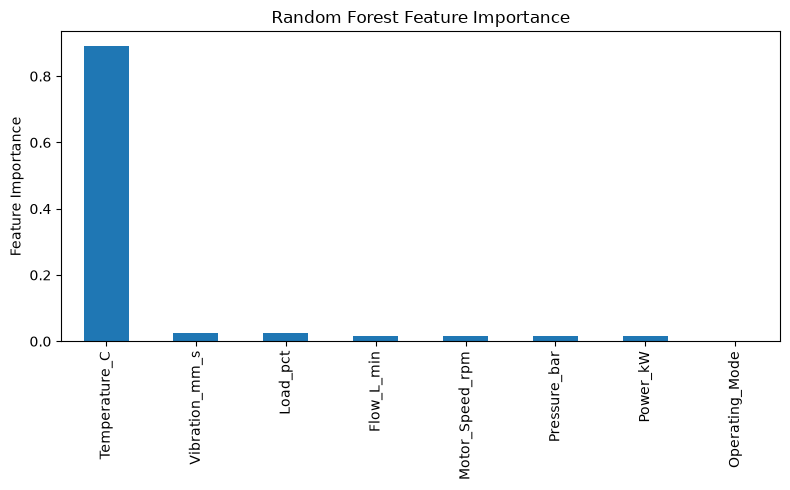

In [31]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=feature_col
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))

importance.plot(kind='bar')

plt.ylabel('Feature Importance')
plt.title('Random Forest Feature Importance')

plt.tight_layout()
plt.show()

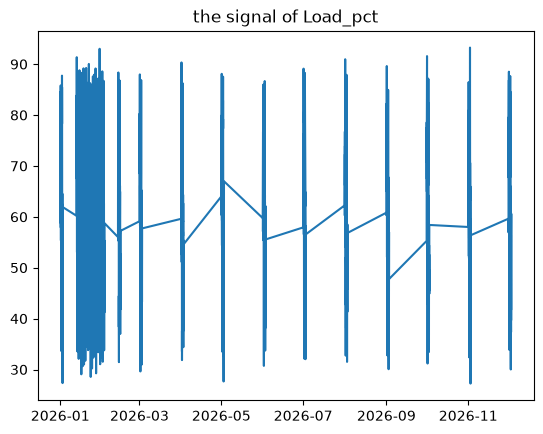

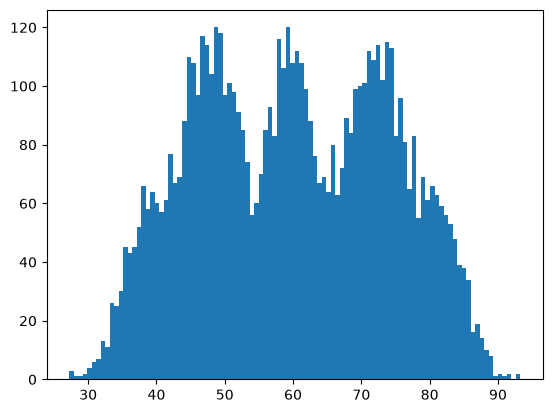

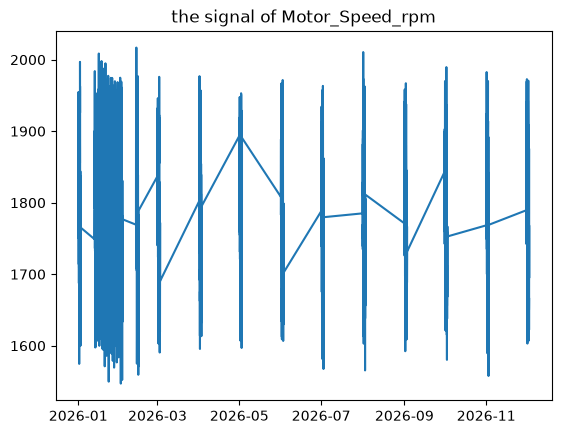

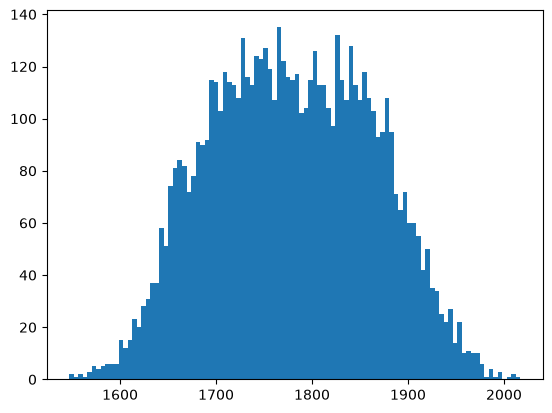

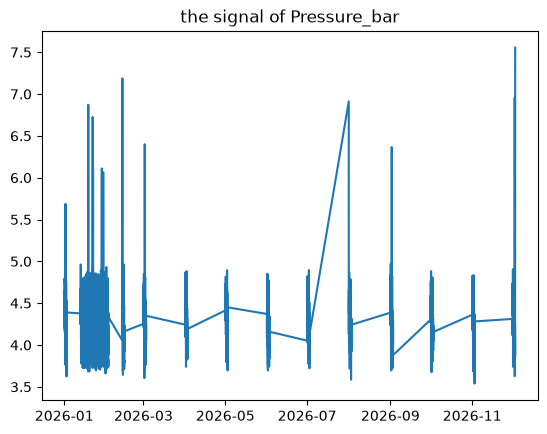

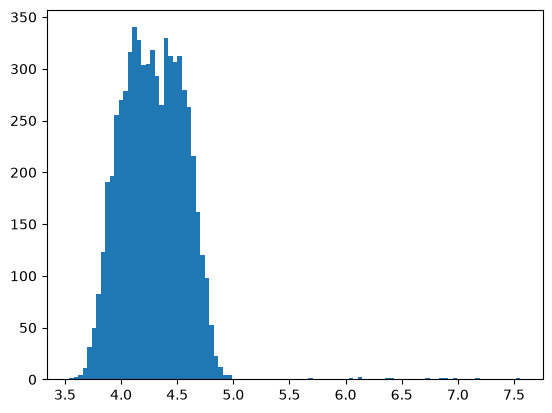

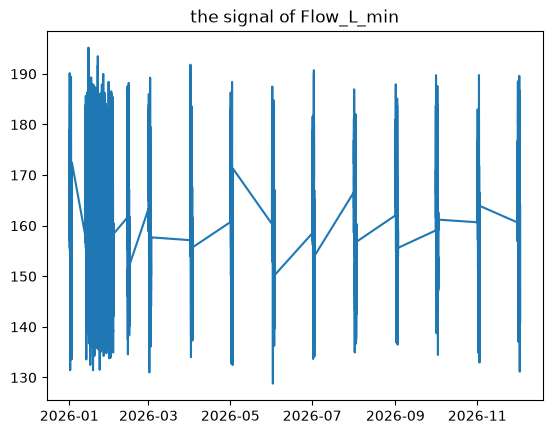

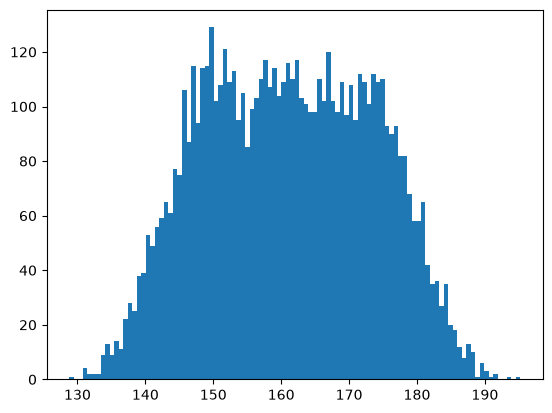

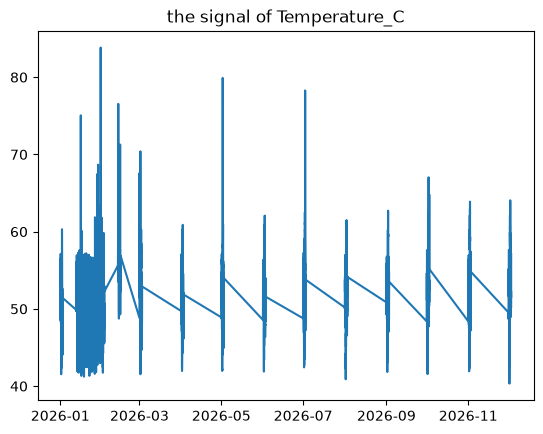

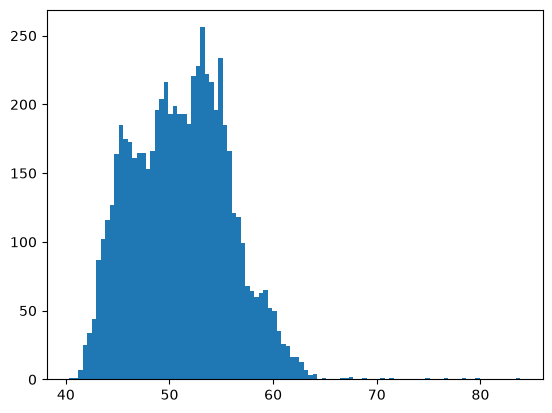

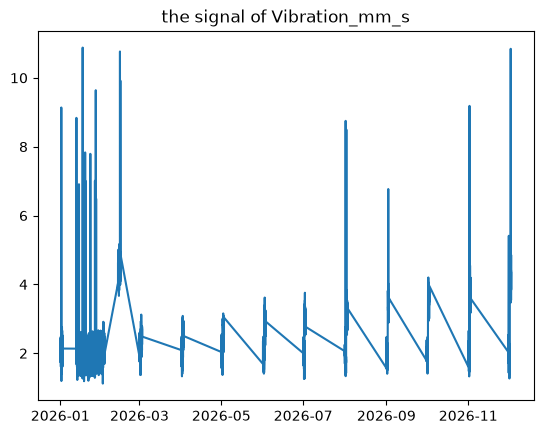

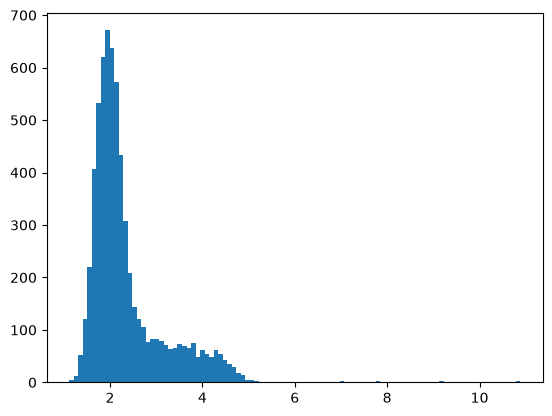

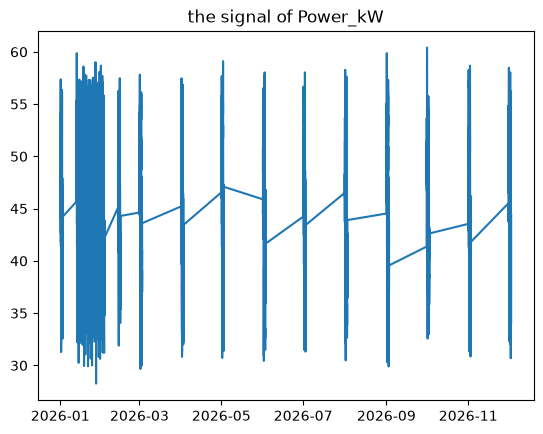

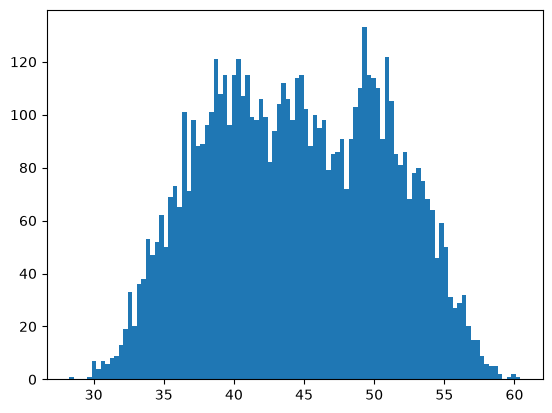

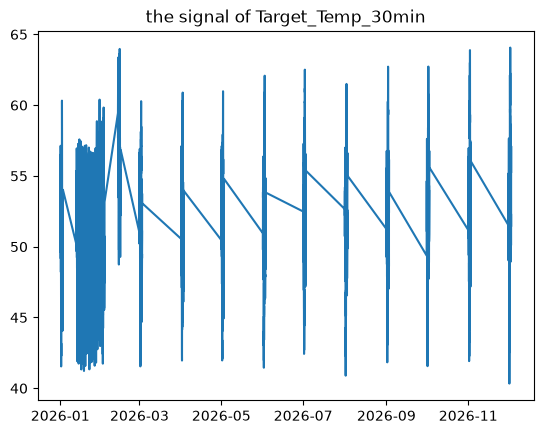

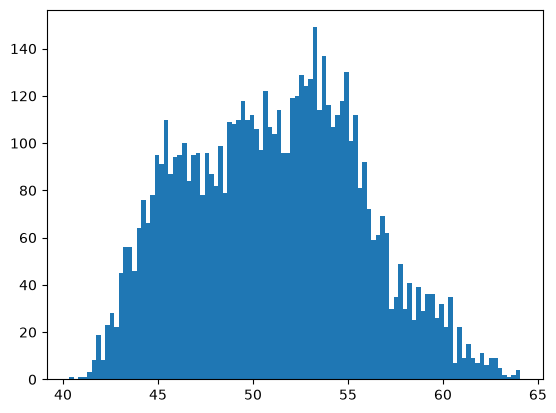

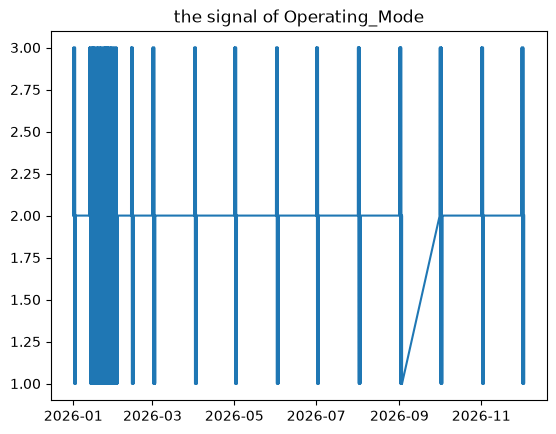

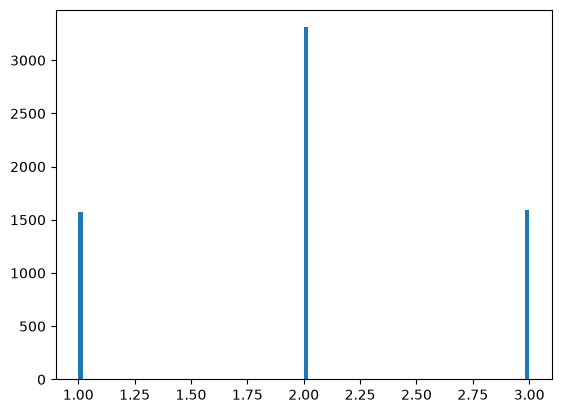

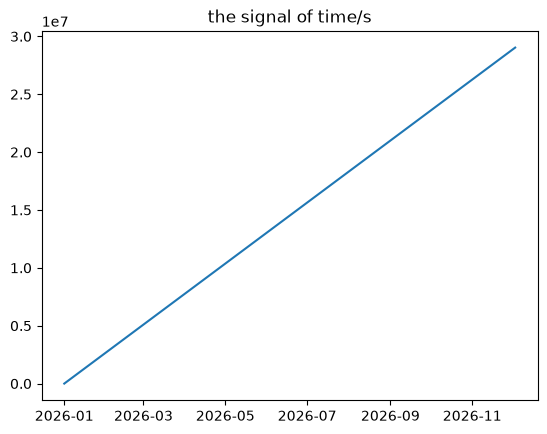

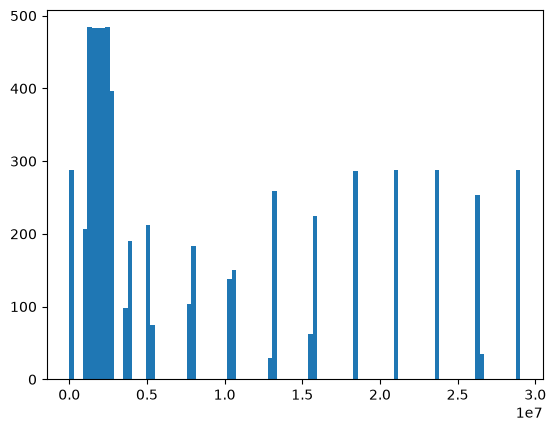

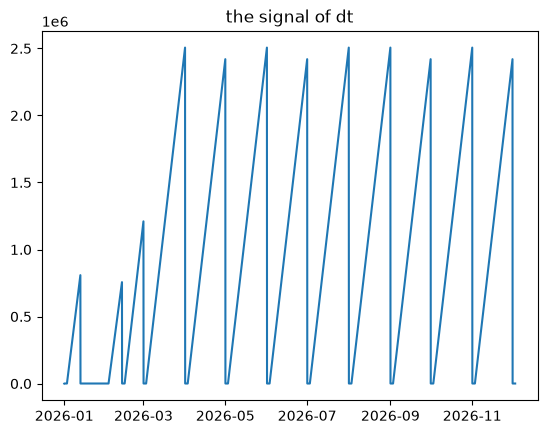

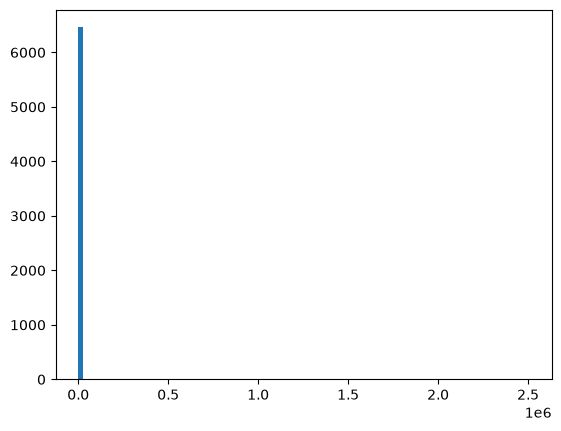

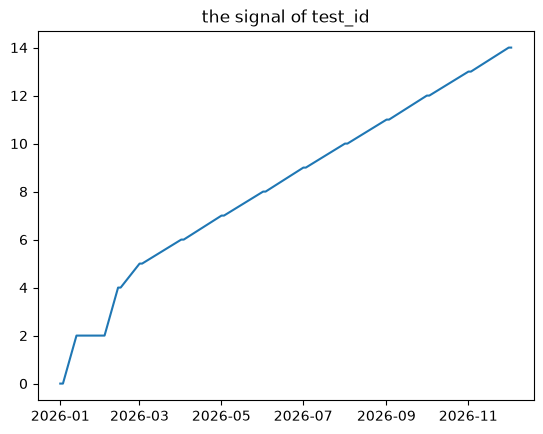

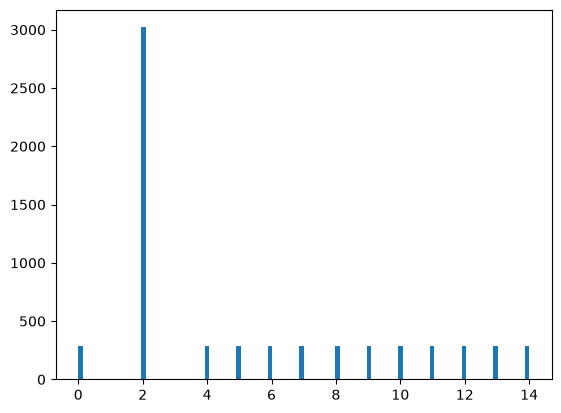

In [60]:
for col in df.select_dtypes(include='number').columns:
    plt.figure()
    plt.plot(df[col])
    plt.title(f'the signal of {col}')
    plt.figure()
    plt.hist(df[col],bins=100)
    plt.show()



In [94]:
df.dtypes

Machine_ID               str
Load_pct             float64
Motor_Speed_rpm      float64
Pressure_bar         float64
Flow_L_min           float64
Temperature_C        float64
Vibration_mm_s       float64
Power_kW             float64
Target_Temp_30min    float64
Operating_Mode         int64
time/s               float64
dt                   float64
test_id                int64
dtype: object

In [95]:
df['dt'].dtype

dtype('float64')

In [96]:
type(df)

pandas.DataFrame

In [101]:
load=df['Load_pct']
load.dtype

dtype('float64')

In [98]:
type(load)

pandas.Series

In [102]:
df.shape

(6472, 13)

In [103]:
df.index

DatetimeIndex(['2026-01-01 00:00:00', '2026-01-01 00:10:00',
               '2026-01-01 00:20:00', '2026-01-01 00:30:00',
               '2026-01-01 00:40:00', '2026-01-01 00:50:00',
               '2026-01-01 01:00:00', '2026-01-01 01:10:00',
               '2026-01-01 01:20:00', '2026-01-01 01:30:00',
               ...
               '2026-12-02 22:20:00', '2026-12-02 22:30:00',
               '2026-12-02 22:40:00', '2026-12-02 22:50:00',
               '2026-12-02 23:00:00', '2026-12-02 23:10:00',
               '2026-12-02 23:20:00', '2026-12-02 23:30:00',
               '2026-12-02 23:40:00', '2026-12-02 23:50:00'],
              dtype='datetime64[us]', name='Datetime', length=6472, freq=None)

In [104]:
import pandas as pd
import inspect

print(inspect.getfile(pd.DataFrame))

/opt/conda/lib/python3.11/site-packages/pandas/__init__.py


In [106]:
pd.DataFrame.__mro__

(pandas.DataFrame,
 pandas.core.generic.NDFrame,
 pandas.core.base.PandasObject,
 pandas.core.accessor.DirNamesMixin,
 pandas.core.indexing.IndexingMixin,
 pandas.core.arraylike.OpsMixin,
 object)

In [107]:
pd.DataFrame.__bases__

(pandas.core.generic.NDFrame, pandas.core.arraylike.OpsMixin)

In [1]:
! pip install inspect

ERROR: Could not find a version that satisfies the requirement inspect (from versions: none)
ERROR: No matching distribution found for inspect
